In [1]:
import os
from glob import glob
import mrcfile
import matplotlib.pyplot as plt
from core.vtk_utilities import *
from core.utilities import *
from core.widgets_utilities import *
from core.all_features2 import all_features2
from core.tk_utilities import *


1: 6qzp_10A.pns
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/6qzp_10A.pns
		-TOMOGRAM 0 DENSITY STATISTICS:
			+Membranes: 0 #,  0.0 um**3,  0.0 %
			+Actin: 0 #,  0.0 um**3,  0.0 %
			+Microtublues: 0 #,  0.0 um**3,  0.0 %
			+Proteins: 10 #,  7.807200000000001e-05 um**3,  0.5522495156003839 %
			+Membrane proteins: 0 #,  0.0 um**3,  0.0 %
			+Total: 10 #,  7.807200000000001e-05 um**3,  0.5522495156003839 %
			+Time for generation:  0.016714207331339517 mins
Successfully terminated. (Sat Dec 21 14:03:57 2024)
2: 6cvm_10A.pns
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/6cvm_10A.pns
		-TOMOGRAM 0 DENSITY STATISTICS:
			+Membranes: 0 #,  0.0 um**3,  0.0 %
			+Actin: 0 #,  0.0 um**3,  0.0 %
			+Microtublues: 0 #,  0.0 um**3,  0.0 %
			+Proteins: 63 #,  7.610700000000001e-05 um**3,  0.5383499062890462 %
			+Membrane proteins: 0 #,  0.0 um**3,  0.0 %
			+Total: 63 #,  7.610700000000001e-05 um**3,  0.5

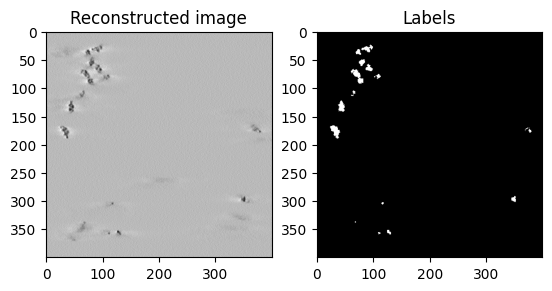

In [2]:

# Define the directory containing the .pns files
pns_directory = "/home/tomo/kaggle/polnet/data/in_10A_czii"

# List all .pns files in the directory
pns_files = [f for f in os.listdir(pns_directory) if f.endswith('.pns')]

for i, pns_file in enumerate(pns_files):
    print(f"{i + 1}: {pns_file}")
    # Select the first .pns file
    selected_pns_file = os.path.join(pns_directory, pns_file)

    # Define the output directory
    output_directory = os.path.realpath(os.getcwd() + '/../data') + f'/../data_generated/polnet_test_pns/{selected_pns_file.split("/")[-1].split(".")[0]}'

    # Define the parameters for the all_features2 function
    ntomos = 1
    voi_shape = (400, 400, 100)
    voi_off = ((4, 396), (4, 396), (4, 96))
    voi_size = 10
    mmer_tries = 20
    pmer_tries = 100
    membranes_list = []# ["/home/tomo/kaggle/polnet/data/in_mbs/sphere.mbs"]
    helix_list = []#["/home/tomo/kaggle/polnet/data/in_helix/actin.hns"]
    proteins_list = [selected_pns_file]
    mb_proteins_list = []#["/home/tomo/kaggle/polnet/data/in_10A/mb_4pe5_10A.pms"]
    surf_dec = 0.9
    tilt_angs = range(-60, 61, 3)
    detector_snr = [1, 2]
    malign_mn = 1
    malign_mx = 1.5
    malign_sg = 0.2

    # Generate the synthetic dataset
    all_features2(ntomos, voi_shape, output_directory, voi_off, voi_size, mmer_tries, pmer_tries,
                membranes_list, helix_list, proteins_list, mb_proteins_list, surf_dec, tilt_angs,
                detector_snr, malign_mn, malign_mx, malign_sg)

    # Visualize the generated data
    image_file = glob(os.path.join(output_directory, 'tomos', 'tomo_rec_0_snr*.mrc'))[0]
    with mrcfile.open(image_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 1)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Reconstructed image')

    label_file = os.path.join(output_directory, 'tomos', 'tomo_lbls_0.mrc')
    with mrcfile.open(label_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 2)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Labels')

    plt.savefig(os.path.join(output_directory, 'visualization.png'))

1: mb_4pe5_10A.pms
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_mbs/ellipse.mbs
Membrane 1, total occupancy: 0.0043388125, volume: 69421000, thickness: 25.674651352344252, layer_s: 1.8125899566166002, radius (avg): 618.5207178285295
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A/6z6u_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A/mb_4pe5_10A.pms
		-TOMOGRAM 0 DENSITY STATISTICS:
			+Membranes: 1 #,  0.000173282 um**3,  1.2257262598917118 %
			+Actin: 0 #,  0.0 um**3,  0.0 %
			+Microtublues: 0 #,  0.0 um**3,  0.0 %
			+Proteins: 63 #,  7.380900000000001e-05 um**3,  0.5220947906669322 %
			+Membrane proteins: 9 #,  1.0659e-05 um**3,  0.07539742272241638 %
			+Total: 73 #,  0.00025775 um**3,  1.8232184732810606 %
			+Time for generation:  0.25119750102361044 mins
Successfully terminated. (Sat Nov 30 20:01:25 2024)
2: mb_5kxi_10A.pms
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_mbs/ellipse.mbs


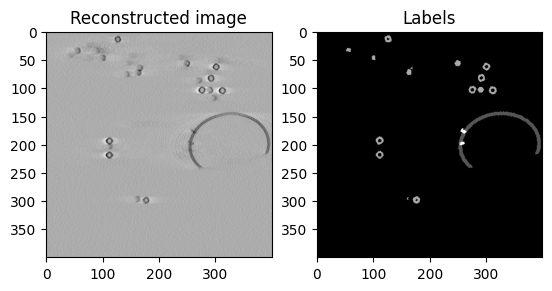

In [11]:

# Define the directory containing the .pns files
directory = "/home/tomo/kaggle/polnet/data/in_10A"

# List all .pns files in the directory
files = [f for f in os.listdir(directory) if f.endswith('.pms')]

for i, file in enumerate(files):
    print(f"{i + 1}: {file}")
    selected_file = os.path.join(directory, file)

    # Define the output directory
    output_directory = os.path.realpath(os.getcwd() + '/../data') + f'/../data_generated/polnet_test_pms/{selected_file.split("/")[-1].split(".")[0]}'

    # Define the parameters for the all_features2 function
    ntomos = 1
    voi_shape = (400, 400, 100)
    voi_off = ((4, 396), (4, 396), (4, 96))
    voi_size = 10
    mmer_tries = 20
    pmer_tries = 100
    membranes_list = ["/home/tomo/kaggle/polnet/data/in_mbs/ellipse.mbs"]# ["/home/tomo/kaggle/polnet/data/in_mbs/sphere.mbs"]
    helix_list = []#["/home/tomo/kaggle/polnet/data/in_helix/actin.hns"]
    proteins_list = ["/home/tomo/kaggle/polnet/data/in_10A/6z6u_10A.pns"]
    mb_proteins_list = [selected_file]#["/home/tomo/kaggle/polnet/data/in_10A/mb_4pe5_10A.pms"]
    surf_dec = 0.9
    tilt_angs = range(-60, 61, 3)
    detector_snr = [1, 2]
    malign_mn = 1
    malign_mx = 1.5
    malign_sg = 0.2

    # Generate the synthetic dataset
    all_features2(ntomos, voi_shape, output_directory, voi_off, voi_size, mmer_tries, pmer_tries,
                membranes_list, helix_list, proteins_list, mb_proteins_list, surf_dec, tilt_angs,
                detector_snr, malign_mn, malign_mx, malign_sg)

    # Visualize the generated data
    image_file = glob(os.path.join(output_directory, 'tomos', 'tomo_rec_0_snr*.mrc'))[0]
    with mrcfile.open(image_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 1)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Reconstructed image')

    label_file = os.path.join(output_directory, 'tomos', 'tomo_lbls_0.mrc')
    with mrcfile.open(label_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 2)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Labels')

    plt.savefig(os.path.join(output_directory, 'visualization.png'))

1: mt.hns
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_helix/mt.hns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A/6z6u_10A.pns
		-TOMOGRAM 0 DENSITY STATISTICS:
			+Membranes: 0 #,  0.0 um**3,  0.0 %
			+Actin: 0 #,  0.0 um**3,  0.0 %
			+Microtublues: 4 #,  0.00010152900000000001 um**3,  0.7181747754558789 %
			+Proteins: 62 #,  7.2587e-05 um**3,  0.513450860601561 %
			+Membrane proteins: 0 #,  0.0 um**3,  0.0 %
			+Total: 66 #,  0.000174116 um**3,  1.2316256360574398 %
			+Time for generation:  0.07953392267227173 mins
Successfully terminated. (Sat Nov 30 19:54:47 2024)
2: actin.hns
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_helix/actin.hns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A/6z6u_10A.pns
		-TOMOGRAM 0 DENSITY STATISTICS:
			+Membranes: 0 #,  0.0 um**3,  0.0 %
			+Actin: 105 #,  0.00046807600000000005 um**3,  3.3109788946634557 %
			+Microtublues: 0 #,  0.0 um**3,  0.0 %
			+Protein

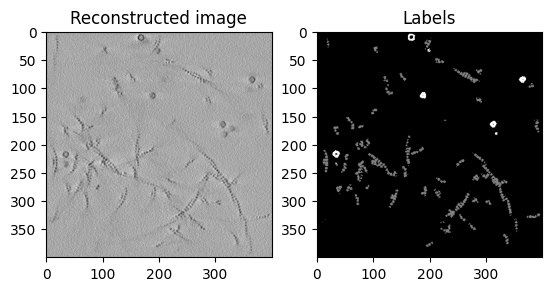

In [8]:

# Define the directory containing the .pns files
directory = "/home/tomo/kaggle/polnet/data/in_helix"

# List all .pns files in the directory
files = [f for f in os.listdir(directory) if f.endswith('.hns')]

for i, file in enumerate(files):
    print(f"{i + 1}: {file}")
    selected_file = os.path.join(directory, file)

    # Define the output directory
    output_directory = os.path.realpath(os.getcwd() + '/../data') + f'/../data_generated/polnet_test_hns/{selected_file.split("/")[-1].split(".")[0]}'

    # Define the parameters for the all_features2 function
    ntomos = 1
    voi_shape = (400, 400, 100)
    voi_off = ((4, 396), (4, 396), (4, 96))
    voi_size = 10
    mmer_tries = 20
    pmer_tries = 100
    membranes_list = []# ["/home/tomo/kaggle/polnet/data/in_mbs/sphere.mbs"]
    helix_list = [selected_file]#["/home/tomo/kaggle/polnet/data/in_helix/actin.hns"]
    proteins_list = ["/home/tomo/kaggle/polnet/data/in_10A/6z6u_10A.pns"]
    mb_proteins_list = []#["/home/tomo/kaggle/polnet/data/in_10A/mb_4pe5_10A.pms"]
    surf_dec = 0.9
    tilt_angs = range(-60, 61, 3)
    detector_snr = [1, 2]
    malign_mn = 1
    malign_mx = 1.5
    malign_sg = 0.2

    # Generate the synthetic dataset
    all_features2(ntomos, voi_shape, output_directory, voi_off, voi_size, mmer_tries, pmer_tries,
                membranes_list, helix_list, proteins_list, mb_proteins_list, surf_dec, tilt_angs,
                detector_snr, malign_mn, malign_mx, malign_sg)

    # Visualize the generated data
    image_file = glob(os.path.join(output_directory, 'tomos', 'tomo_rec_0_snr*.mrc'))[0]
    with mrcfile.open(image_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 1)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Reconstructed image')

    label_file = os.path.join(output_directory, 'tomos', 'tomo_lbls_0.mrc')
    with mrcfile.open(label_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 2)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Labels')

    plt.savefig(os.path.join(output_directory, 'visualization.png'))

1: sphere.mbs
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_mbs/sphere.mbs
Membrane 1, total occupancy: 0.00087825, volume: 14052000, thickness: 29.36840007047167, layer_s: 0.824822551311974, radius (avg): 850.4527771543887
Membrane 2, total occupancy: 0.0012624375, volume: 6147000, thickness: 28.580900964691796, layer_s: 0.6604154756531238, radius (avg): 149.74826412459814
Membrane 3, total occupancy: 0.0039016875, volume: 42228000, thickness: 34.64616367495107, layer_s: 0.7951430167161275, radius (avg): 1665.021892502069
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A/6z6u_10A.pns
		-TOMOGRAM 0 DENSITY STATISTICS:
			+Membranes: 3 #,  7.632e-05 um**3,  0.5398565814968401 %
			+Actin: 0 #,  0.0 um**3,  0.0 %
			+Microtublues: 0 #,  0.0 um**3,  0.0 %
			+Proteins: 63 #,  7.3835e-05 um**3,  0.5222787040725785 %
			+Membrane proteins: 0 #,  0.0 um**3,  0.0 %
			+Total: 66 #,  0.00015015500000000002 um**3,  1.0621352855694186 %
			+Time for genera

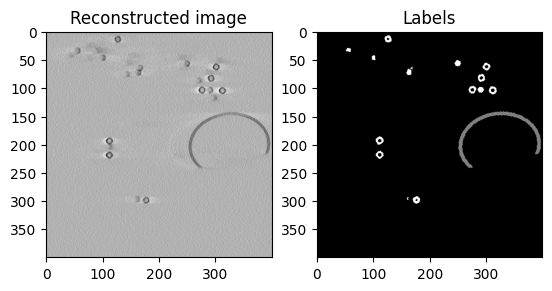

In [10]:

# Define the directory containing the .pns files
directory = "/home/tomo/kaggle/polnet/data/in_mbs"

# List all .pns files in the directory
files = [f for f in os.listdir(directory) if f.endswith('.mbs')]

for i, file in enumerate(files):
    print(f"{i + 1}: {file}")
    selected_file = os.path.join(directory, file)

    # Define the output directory
    output_directory = os.path.realpath(os.getcwd() + '/../data') + f'/../data_generated/polnet_test_mbs/{selected_file.split("/")[-1].split(".")[0]}'

    # Define the parameters for the all_features2 function
    ntomos = 1
    voi_shape = (400, 400, 100)
    voi_off = ((4, 396), (4, 396), (4, 96))
    voi_size = 10
    mmer_tries = 20
    pmer_tries = 100
    membranes_list = [selected_file]# ["/home/tomo/kaggle/polnet/data/in_mbs/sphere.mbs"]
    helix_list = []#["/home/tomo/kaggle/polnet/data/in_helix/actin.hns"]
    proteins_list = ["/home/tomo/kaggle/polnet/data/in_10A/6z6u_10A.pns"]
    mb_proteins_list = []#["/home/tomo/kaggle/polnet/data/in_10A/mb_4pe5_10A.pms"]
    surf_dec = 0.9
    tilt_angs = range(-60, 61, 3)
    detector_snr = [1, 2]
    malign_mn = 1
    malign_mx = 1.5
    malign_sg = 0.2

    # Generate the synthetic dataset
    all_features2(ntomos, voi_shape, output_directory, voi_off, voi_size, mmer_tries, pmer_tries,
                membranes_list, helix_list, proteins_list, mb_proteins_list, surf_dec, tilt_angs,
                detector_snr, malign_mn, malign_mx, malign_sg)

    # Visualize the generated data
    image_file = glob(os.path.join(output_directory, 'tomos', 'tomo_rec_0_snr*.mrc'))[0]
    with mrcfile.open(image_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 1)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Reconstructed image')

    label_file = os.path.join(output_directory, 'tomos', 'tomo_lbls_0.mrc')
    with mrcfile.open(label_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 2)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Labels')

    plt.savefig(os.path.join(output_directory, 'visualization.png'))